# 06 — RGCN Model, Mini-Batch (GPU-Friendly)

Same `RGCNConv` architecture as [05_rgcn_model.ipynb](05_rgcn_model.ipynb), but trained with PyG's
`NeighborLoader` mini-batching instead of full-batch — mirroring how `../gnn_fraud_detection.py` already
trains its GraphSAGE model, now applied to RGCN.

**Why this notebook exists.** Running notebook 05 full-batch actually OOM-killed a 32 GB Workbench VM. Root
cause, documented in [`../resource_requirements.md`](../resource_requirements.md): `RGCNConv` aggregates
**separately per relation** before applying that relation's weight, producing a full dense
`[num_nodes × hidden]` intermediate **for each of the 12 relations, at every layer** — autograd has to keep
all of them alive for backward. At the full graph's 1,097,231 nodes that's ~25–35 GB, regardless of how
sparse any individual relation actually is. The fix documented there was simply a bigger CPU instance
(`n2-highmem-8`, 64 GB) with the architecture left unchanged.

**This notebook takes the other documented fix instead**: mini-batch training. `NeighborLoader` samples a
bounded k-hop neighborhood around a small batch of seed nodes (2,048 at a time here, with fanout
`[15, 10, 5]` matching `../gnn_fraud_detection.py`'s own production settings) instead of handing `RGCNConv`
the whole 1.1M-node graph at once. The per-relation dense intermediate is now sized to the **sampled
subgraph**, not the full graph — typically a few thousand to a few tens of thousands of nodes given this
graph's ~1.1 average degree, not 1.1M. That shrinks the dominant memory term by roughly two orders of
magnitude, which is *specifically* what makes a GPU with limited VRAM (a T4's 16 GB or an L4's 24 GB — see
[`../deploy/gcp_workbench_training.md`](../deploy/gcp_workbench_training.md) §11) viable for RGCN again; the
earlier full-batch notebook needed system RAM on the order of ~25–35 GB, well past either GPU's VRAM.

The model class itself (`FraudRGCN`) is **unchanged** from notebook 05 — `RGCNConv` operates identically on a
sampled subgraph as on the full graph, since message passing only ever looks at local edges regardless of
how the batch was assembled. Only the training/evaluation loop changes.

Requires: `pip install torch torch-geometric`. For faster neighbor sampling, PyG also recommends
`pip install pyg-lib` (optional — falls back to a pure-Python sampler without it, just slower).


In [12]:
import sys, pathlib, json, time
sys.path.append(str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_utils import (PROCESSED_DIR, RESULTS_DIR, RANDOM_SEED, set_seed,
                          save_metrics, load_metrics, save_predictions, load_predictions)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.loader import NeighborLoader
    from torch_geometric.nn import RGCNConv, GraphNorm
except ImportError as e:
    raise ImportError(
        "This notebook needs torch + torch-geometric. Install with:\n"
        "  pip install torch torchvision\n"
        "  pip install torch-geometric\n"
        "(see https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html "
        "for platform-specific wheels)."
    ) from e

from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                              precision_recall_curve, confusion_matrix, classification_report)

set_seed()
plt.rcParams["figure.figsize"] = (7, 5)
%matplotlib inline

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")  # Apple Silicon
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("Note: this notebook is written for GPU (that's the whole point of mini-batching here), but "
          "mini-batch training also works on CPU — it'll just be slower per batch, not infeasible.")


Using device: cuda


## 1. Load Preprocessed Graph Artifacts (Including Edge Types)

Identical to notebook 05 — same `PROCESSED_DIR` artifacts, same `Data` object with `edge_type` attached.
The difference starts in Section 3: this `data` object stays on **CPU** (it's `NeighborLoader`'s job to draw
small subgraphs from it and hand only those to the GPU, batch by batch) rather than being moved to `DEVICE`
as a whole the way notebook 05 does.


In [13]:
features = np.load(PROCESSED_DIR / "features.npy")
labels = np.load(PROCESSED_DIR / "labels.npy")
split_arr = np.load(PROCESSED_DIR / "split.npy", allow_pickle=True)
edge_index_np = np.load(PROCESSED_DIR / "edge_index.npy")
edge_type_np = np.load(PROCESSED_DIR / "edge_type.npy")
with open(PROCESSED_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

# EDGE_TYPE_COLS from 03_preprocessing_gnn_features.ipynb, for readable relation names below
EDGE_TYPE_COLS = ["card1", "card2", "card3", "card4", "card5", "card6",
                   "addr1", "addr2", "P_emaildomain", "R_emaildomain",
                   "DeviceType", "DeviceInfo"]

NUM_RELATIONS = int(edge_type_np.max()) + 1
print(f"features: {features.shape}, edges: {edge_index_np.shape[1]:,}, "
      f"n_features: {len(feature_names)}, n_relations: {NUM_RELATIONS}")

rel_counts = pd.Series(edge_type_np).value_counts().sort_index()
for rel_idx, count in rel_counts.items():
    name = EDGE_TYPE_COLS[rel_idx] if rel_idx < len(EDGE_TYPE_COLS) else f"relation_{rel_idx}"
    print(f"  relation {rel_idx:2d} ({name:16s}): {count:>10,d} edges")

x = torch.tensor(features, dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.float32)
edge_index = torch.tensor(edge_index_np, dtype=torch.long)
edge_type = torch.tensor(edge_type_np, dtype=torch.long)

train_mask = torch.tensor(split_arr == "train", dtype=torch.bool)
valid_mask = torch.tensor(split_arr == "valid", dtype=torch.bool)
test_mask = torch.tensor(split_arr == "test", dtype=torch.bool)

# NOTE: stays on CPU — NeighborLoader samples from this directly and moves only the sampled
# mini-batch to DEVICE each iteration (see Section 3). Do not call data.to(DEVICE) here.
data = Data(x=x, y=y, edge_index=edge_index, edge_type=edge_type,
            train_mask=train_mask, valid_mask=valid_mask, test_mask=test_mask)
print(data)
print(f"train: {train_mask.sum().item():,}  valid: {valid_mask.sum().item():,}  test: {test_mask.sum().item():,}")


features: (1097231, 117), edges: 1,161,398, n_features: 117, n_relations: 12
  relation  0 (card1           ):    899,694 edges
  relation  1 (card2           ):     49,098 edges
  relation  2 (card3           ):      8,842 edges
  relation  3 (card4           ):        490 edges
  relation  4 (card5           ):      9,360 edges
  relation  5 (card6           ):        592 edges
  relation  6 (addr1           ):     16,162 edges
  relation  7 (addr2           ):      3,906 edges
  relation  8 (P_emaildomain   ):      5,882 edges
  relation  9 (R_emaildomain   ):      6,168 edges
  relation 10 (DeviceType      ):        294 edges
  relation 11 (DeviceInfo      ):    160,910 edges
Data(x=[1097231, 117], edge_index=[2, 1161398], y=[1097231], edge_type=[1161398], train_mask=[1097231], valid_mask=[1097231], test_mask=[1097231])
train: 472,432  valid: 118,108  test: 506,691


## 2. RGCN Model Definition

**Unchanged from notebook 05.** `RGCNConv` doesn't know or care whether the `edge_index`/`edge_type` it's
given describe the full graph or a sampled subgraph — it just does relation-specific aggregation over
whatever local edges it's handed. That's precisely what makes mini-batching a training-*loop* change rather
than a model-architecture change.


In [14]:
class FraudRGCN(nn.Module):
    def __init__(self, in_channels, num_relations, hidden_channels=128, num_layers=3,
                 dropout=0.3, num_bases=None):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout

        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.input_norm = GraphNorm(hidden_channels)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_channels, hidden_channels, num_relations=num_relations,
                                        num_bases=num_bases))
            self.norms.append(GraphNorm(hidden_channels))

        classifier_in = hidden_channels * (num_layers + 1)  # skip-connected concat
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.LayerNorm(hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1),
        )

    def forward(self, x, edge_index, edge_type):
        h = F.relu(self.input_norm(self.input_proj(x)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        skip = [h]
        for conv, norm in zip(self.convs, self.norms):
            h = conv(h, edge_index, edge_type)
            h = F.relu(norm(h))
            h = F.dropout(h, p=self.dropout, training=self.training)
            skip.append(h)
        h = torch.cat(skip, dim=-1)
        return self.classifier(h).squeeze(-1)


## 3. Mini-Batch Training Setup

`NeighborLoader(data, num_neighbors=[15, 10, 5], ...)` draws, for each batch of seed nodes, a 3-hop
neighborhood (one hop per conv layer) capped at 15/10/5 neighbors per hop — the same fanout
`../gnn_fraud_detection.py` uses for its GraphSAGE model, reused here for consistency. Given this graph's
~1.1 average degree, real sampled subgraphs will typically be far smaller than the fanout product suggests
(most nodes simply don't have 15 real neighbors to sample) — that's exactly the memory win over full-batch.

**The `batch.batch_size` convention**: `NeighborLoader` always places the seed nodes first in the returned
`Data`'s node ordering, so `batch.x[:batch.batch_size]` / `batch.y[:batch.batch_size]` /
`out[:batch.batch_size]` are the seeds, and everything after that up to `batch.num_nodes` is sampled-neighbor
context used only for message passing — loss and metrics must only ever be computed on the first
`batch.batch_size` rows, never the whole batch.


In [15]:
HIDDEN_DIM = 128
NUM_LAYERS = 3
DROPOUT = 0.3
LR = 1e-4              # lowered from 1e-3 — that LR was tuned for notebook 05's full-batch (1 step/epoch)
                        # regime; at 231 noisy mini-batch steps/epoch it destabilized training within the
                        # first ~10 epochs and never recovered (see notebook discussion)
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 60
NUM_BASES = 6          # same basis-decomposition regularization as notebook 05
NUM_NEIGHBORS = [15, 10, 5]   # one fanout per conv layer, matches ../gnn_fraud_detection.py
BATCH_SIZE = 2048             # seed nodes per training batch, matches ../gnn_fraud_detection.py
EVAL_BATCH_SIZE = 8192        # larger is fine at eval time — no backward pass to fit in memory

model = FraudRGCN(in_channels=x.shape[1], num_relations=NUM_RELATIONS, hidden_channels=HIDDEN_DIM,
                   num_layers=NUM_LAYERS, dropout=DROPOUT, num_bases=NUM_BASES).to(DEVICE)

# pos_weight from the FULL train-label distribution (not per-batch) — stays a stable global constant
n_pos = (data.y[data.train_mask] == 1).sum()
n_neg = (data.y[data.train_mask] == 0).sum()
pos_weight = (n_neg / n_pos).clamp(min=1.0).to(DEVICE)
print(f"pos_weight (class imbalance correction): {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

CKPT_PATH = RESULTS_DIR / "best_rgcn_minibatch_model.pt"

train_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    input_nodes=data.train_mask,
    shuffle=True,
)
valid_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=EVAL_BATCH_SIZE,
    input_nodes=data.valid_mask,
    shuffle=False,
)
print(f"train batches/epoch: {len(train_loader)}   valid batches/epoch: {len(valid_loader)}")


pos_weight (class imbalance correction): 27.46
train batches/epoch: 231   valid batches/epoch: 15


In [11]:
!pip uninstall -y pyg-lib



Found existing installation: pyg_lib 0.4.0+pt23cu121
Uninstalling pyg_lib-0.4.0+pt23cu121:
  Successfully uninstalled pyg_lib-0.4.0+pt23cu121


In [13]:
!python -c "import torch; print(torch.__version__, torch.version.cuda)"   # e.g. 2.5.1+cu121


2.12.1+cu130 13.0


In [14]:
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.12.1+cu130.html   # use your real version here

Looking in links: https://data.pyg.org/whl/torch-2.12.1+cu130.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 77.8 MB/s  0:00:00


In [16]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_true, all_score = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch.x, batch.edge_index, batch.edge_type)
        seed = batch.batch_size
        probs = torch.sigmoid(out[:seed])
        all_true.append(batch.y[:seed].cpu().numpy())
        all_score.append(probs.cpu().numpy())
    y_true = np.concatenate(all_true)
    y_score = np.concatenate(all_score)
    auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else float("nan")
    return auc, y_true, y_score


best_val_auc = 0.0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    t0 = time.time()
    for batch in train_loader:
        batch = batch.to(DEVICE)
        seed = batch.batch_size

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_type)
        loss = criterion(out[:seed], batch.y[:seed])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1
    scheduler.step()
    epoch_loss /= max(n_batches, 1)
    epoch_time = time.time() - t0

    val_auc, _, _ = evaluate(valid_loader)
    history.append({"epoch": epoch, "loss": epoch_loss, "val_auc": val_auc, "epoch_sec": epoch_time})

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | loss {epoch_loss:.4f} | val AUC {val_auc:.4f} | "
              f"lr {scheduler.get_last_lr()[0]:.6f} | {epoch_time:.1f}s/epoch")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CKPT_PATH)

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print(f"\nBest validation AUC: {best_val_auc:.4f}")
print(f"Median epoch time: {pd.DataFrame(history)['epoch_sec'].median():.1f}s — "
      f"use this to sanity-check the wall-clock estimates in ../resource_requirements.md against a real run.")


Epoch   1 | loss 1.3417 | val AUC 0.5712 | lr 0.000100 | 11.5s/epoch
Epoch   5 | loss 1.3125 | val AUC 0.5757 | lr 0.000098 | 11.5s/epoch
Epoch  10 | loss 1.3048 | val AUC 0.6124 | lr 0.000093 | 11.4s/epoch
Epoch  15 | loss 1.3033 | val AUC 0.5916 | lr 0.000086 | 11.3s/epoch
Epoch  20 | loss 1.2980 | val AUC 0.6685 | lr 0.000075 | 11.2s/epoch
Epoch  25 | loss 1.2901 | val AUC 0.6964 | lr 0.000063 | 11.1s/epoch
Epoch  30 | loss 1.2749 | val AUC 0.6878 | lr 0.000050 | 11.2s/epoch
Epoch  35 | loss 1.2668 | val AUC 0.6918 | lr 0.000038 | 11.2s/epoch
Epoch  40 | loss 1.2574 | val AUC 0.7050 | lr 0.000026 | 11.2s/epoch
Epoch  45 | loss 1.2530 | val AUC 0.7252 | lr 0.000015 | 11.3s/epoch
Epoch  50 | loss 1.2496 | val AUC 0.7267 | lr 0.000008 | 11.4s/epoch
Epoch  55 | loss 1.2367 | val AUC 0.7273 | lr 0.000003 | 11.3s/epoch
Epoch  60 | loss 1.2382 | val AUC 0.7269 | lr 0.000001 | 11.3s/epoch

Best validation AUC: 0.7303
Median epoch time: 11.3s — use this to sanity-check the wall-clock estimat

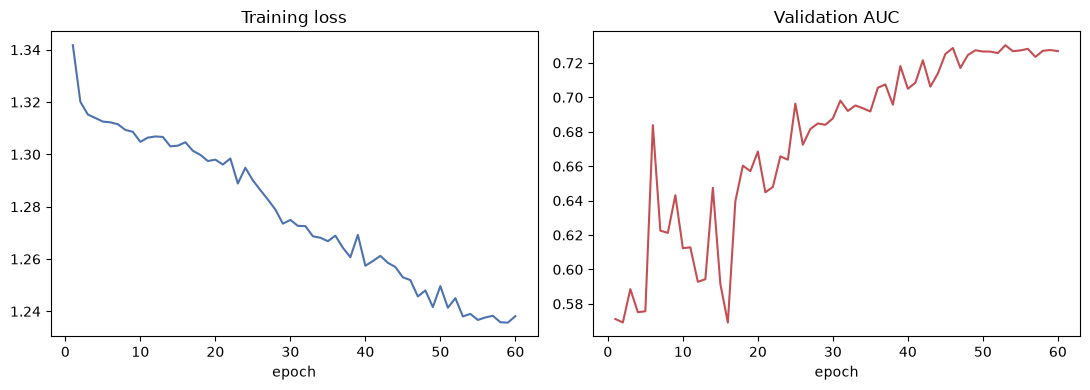

In [17]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df["epoch"], hist_df["loss"], color="#4C72B0")
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch")
axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="#C44E52")
axes[1].set_title("Validation AUC"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()


## 4. Evaluate on Validation Set

In [18]:
rgcn_mb_auc, y_valid, rgcn_mb_valid_scores = evaluate(valid_loader)
rgcn_mb_ap = average_precision_score(y_valid, rgcn_mb_valid_scores)
print(f"RGCN (mini-batch)  |  valid AUC: {rgcn_mb_auc:.4f}  |  valid PR-AUC: {rgcn_mb_ap:.4f}")

print("\nClassification report @ threshold 0.5:")
print(classification_report(y_valid, (rgcn_mb_valid_scores > 0.5).astype(int), digits=4))
print(confusion_matrix(y_valid, (rgcn_mb_valid_scores > 0.5).astype(int)))


RGCN (mini-batch)  |  valid AUC: 0.7287  |  valid PR-AUC: 0.0940

Classification report @ threshold 0.5:
              precision    recall  f1-score   support

         0.0     0.9803    0.8335    0.9010    114044
         1.0     0.1020    0.5310    0.1712      4064

    accuracy                         0.8231    118108
   macro avg     0.5412    0.6822    0.5361    118108
weighted avg     0.9501    0.8231    0.8759    118108

[[95055 18989]
 [ 1906  2158]]


## 5. Which Relations Does the Model Actually Lean On?

Same diagnostic as notebook 05 — purely a function of the trained weights, independent of how batching was
done during training.


In [19]:
first_conv = model.convs[0]
with torch.no_grad():
    if first_conv.num_bases is not None:
        # basis-decomposition: PyG's RGCNConv stores the basis tensor itself as `.weight`
        # (shape [num_bases, in, out]) and the per-relation combination coefficients as `.comp`
        # (shape [num_relations, num_bases]) — there is no separate `.basis` attribute.
        rel_weight = torch.einsum("rb,bio->rio", first_conv.comp, first_conv.weight)
    else:
        rel_weight = first_conv.weight
    rel_norms = rel_weight.flatten(1).norm(dim=1).cpu().numpy()

rel_importance = pd.DataFrame({
    "relation": [EDGE_TYPE_COLS[i] if i < len(EDGE_TYPE_COLS) else f"relation_{i}" for i in range(NUM_RELATIONS)],
    "edge_count": [rel_counts.get(i, 0) for i in range(NUM_RELATIONS)],
    "layer0_weight_norm": rel_norms,
}).sort_values("layer0_weight_norm", ascending=False)
rel_importance


,relation,edge_count,layer0_weight_norm
11,DeviceInfo,160910,4.413841
0,card1,899694,4.378720
6,addr1,16162,4.026086
9,R_emaildomain,6168,3.737716
7,addr2,3906,3.346337
1,card2,49098,3.222010
2,card3,8842,2.857212
4,card5,9360,2.852965
8,P_emaildomain,5882,2.723190
10,DeviceType,294,2.512777


## 6. Save Metrics

In [20]:
rgcn_mb_metrics = {
    "model": "RGCN (mini-batch)",
    "auc": float(rgcn_mb_auc),
    "pr_auc": float(rgcn_mb_ap),
    "n_train": int(data.train_mask.sum().item()),
    "n_valid": int(data.valid_mask.sum().item()),
    "n_features": len(feature_names),
    "n_relations": NUM_RELATIONS,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "num_bases": NUM_BASES,
    "num_neighbors": NUM_NEIGHBORS,
    "batch_size": BATCH_SIZE,
    "num_epochs_trained": len(history),
    "median_epoch_sec": float(pd.DataFrame(history)["epoch_sec"].median()),
}
print("--- rgcn_minibatch metrics (about to save) ---")
print(json.dumps(rgcn_mb_metrics, indent=2, default=float))
save_metrics("rgcn_minibatch", rgcn_mb_metrics)
save_predictions("rgcn_minibatch", y_valid, rgcn_mb_valid_scores)


--- rgcn_minibatch metrics (about to save) ---
{
  "model": "RGCN (mini-batch)",
  "auc": 0.7287403324628539,
  "pr_auc": 0.09396112976726631,
  "n_train": 472432,
  "n_valid": 118108,
  "n_features": 117,
  "n_relations": 12,
  "hidden_dim": 128,
  "num_layers": 3,
  "num_bases": 6,
  "num_neighbors": [
    15,
    10,
    5
  ],
  "batch_size": 2048,
  "num_epochs_trained": 60,
  "median_epoch_sec": 11.292372465133667
}
Saved metrics -> /home/jupyter/GNN-Fraud-Detection/results/rgcn_minibatch_metrics.json
Saved predictions -> /home/jupyter/GNN-Fraud-Detection/results/rgcn_minibatch_preds.npz


PosixPath('/home/jupyter/GNN-Fraud-Detection/results/rgcn_minibatch_preds.npz')

## 7. Compare vs. Baseline, Plain GCN, and Full-Batch RGCN

Loads every metrics/predictions file saved so far. All models were evaluated on the **identical** validation
rows (same `TransactionDT`-based split), so AUC/PR-AUC are directly comparable — including full-batch vs.
mini-batch RGCN, which is the comparison this notebook exists to enable.


In [21]:
model_names = ["baseline_logreg", "baseline_lightgbm", "gcn_gcn", "rgcn", "rgcn_minibatch"]
rows = []
for name in model_names:
    try:
        m = load_metrics(name)
        rows.append({"notebook": name, **m})
    except FileNotFoundError:
        print(f"(skipping {name}: metrics file not found — run its notebook first)")

comparison = pd.DataFrame(rows).set_index("notebook")[["model", "auc", "pr_auc", "n_train", "n_valid", "n_features"]]
comparison


(skipping gcn_gcn: metrics file not found — run its notebook first)
(skipping rgcn: metrics file not found — run its notebook first)


,model,auc,pr_auc,n_train,n_valid,n_features
notebook,,,,,,
baseline_logreg,LogisticRegression,0.805209,0.212554,472432,118108,50
baseline_lightgbm,HistGradientBoosting,0.912338,0.487757,472432,118108,50
rgcn_minibatch,RGCN (mini-batch),0.728740,0.093961,472432,118108,117


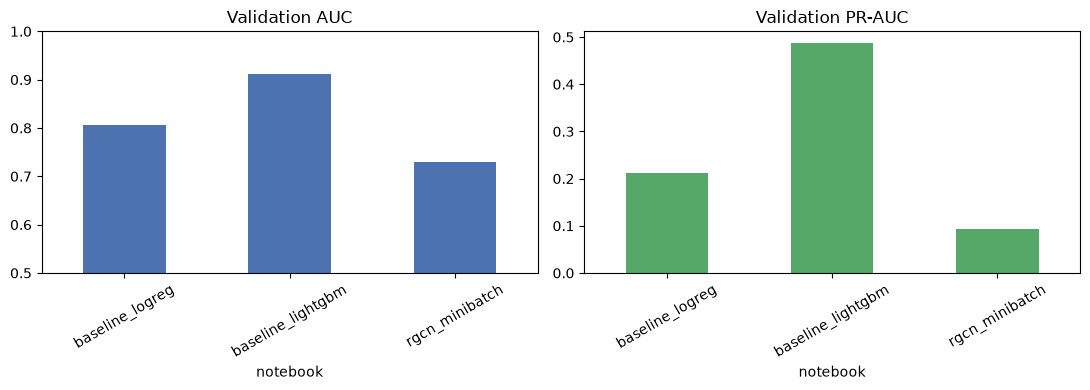

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comparison["auc"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Validation AUC"); axes[0].set_ylim(0.5, 1.0); axes[0].tick_params(axis="x", rotation=30)
comparison["pr_auc"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Validation PR-AUC"); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


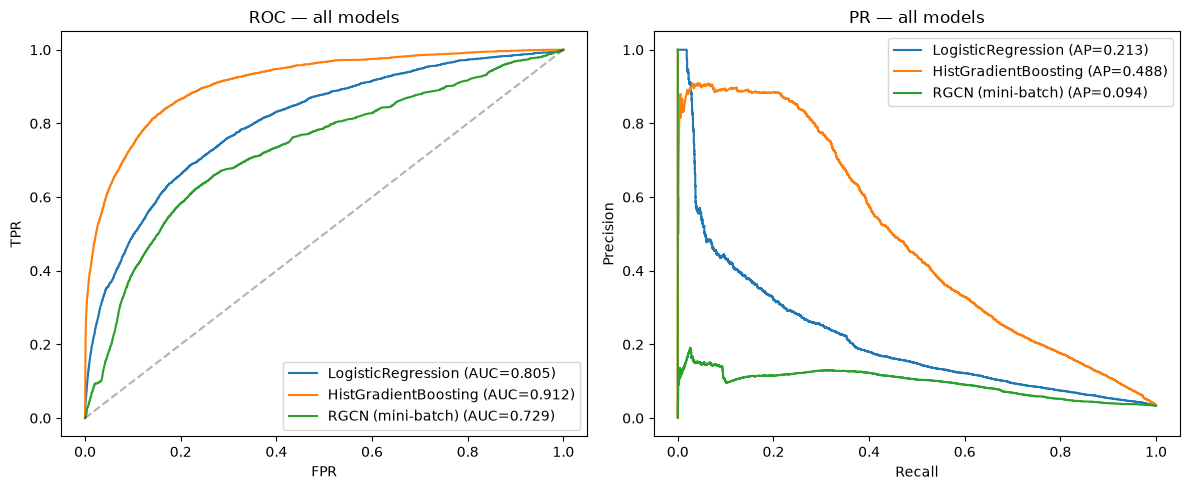

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name in model_names:
    try:
        yt, ys = load_predictions(name)
    except FileNotFoundError:
        continue
    label = load_metrics(name)["model"]
    fpr, tpr, _ = roc_curve(yt, ys)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(yt, ys):.3f})")
    prec, rec, _ = precision_recall_curve(yt, ys)
    axes[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(yt, ys):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC — all models"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PR — all models"); axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Discussion

- **Does mini-batch RGCN roughly match full-batch RGCN's AUC?** Neighbor sampling is stochastic and each
  seed node only ever sees a *sampled* neighborhood (capped at `[15, 10, 5]`) rather than its true full
  neighborhood during training — on this graph's ~1.1 average degree that's a minor approximation (most
  nodes have far fewer real neighbors than the cap anyway), so AUC should land close to notebook 05's
  full-batch number, not systematically worse. A large, consistent gap would suggest the fanout is too
  aggressive relative to how much of this specific graph's structure matters, in which case widening
  `NUM_NEIGHBORS` (at the cost of bigger per-batch subgraphs, and therefore more memory) is the first thing
  to try.
- **The actual point of this notebook**: it makes a T4/L4 GPU viable for RGCN again. Full-batch (notebook 05)
  needed ~25–35 GB — more than either GPU's VRAM, CPU-RAM-only territory. Mini-batching bounds memory to the
  sampled-subgraph size regardless of total graph size, which is *why* `../gnn_fraud_detection.py` was built
  this way in the first place for GraphSAGE; this notebook applies the same reasoning to RGCN.
- **`epoch_sec` in the saved metrics** (Section 6) is a real measured number, not another a priori estimate
  like the ones in `../resource_requirements.md` — worth feeding back into that doc once this notebook has
  actually been run, the same way notebook 05's OOM already corrected that doc's memory estimate once.
- **Still not addressing graph density.** Like notebook 05's discussion says: `MAX_GROUP_SIZE=50` capping and
  the star-hub topology in [03_preprocessing_gnn_features.ipynb](03_preprocessing_gnn_features.ipynb) leave
  the graph itself sparse (avg degree ~1.1) regardless of full-batch vs. mini-batch training — this notebook
  fixes *how* the existing graph is trained on, not what the graph contains.
